# GoEmotions Label-Space and Dataset Analysis

# GoEmotions Label-Space and Dataset Analysis

## Goal

Analyse the complete GoEmotions simplified dataset before running further
continuous or structure-aware emotion representation experiments.

Main questions:

1. How many examples are available for each label in the train, validation,
   and test splits?
2. How reliable were the previous tail-label measurements based on the
   5000/500 subset?
3. Which emotion labels frequently occur together?
4. Are label relationships symmetric or directional?
5. Do pairs such as remorse–sadness, grief–sadness, relief–joy, and
   nervousness–fear show measurable relationships in the annotations?

In [1]:
!pip install -q datasets pandas numpy matplotlib scikit-learn

In [2]:
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datasets import load_dataset
from IPython.display import display

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

RANDOM_SEED = 42

In [3]:
dataset = load_dataset(
    "google-research-datasets/go_emotions",
    "simplified",
)

dataset

README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.77MB            

simplified/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

simplified/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B /  350kB            

simplified/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

simplified/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [4]:
print(dataset)

for split_name, split_dataset in dataset.items():
    print(f"\nSplit: {split_name}")
    print(f"Number of examples: {len(split_dataset):,}")
    print(f"Columns: {split_dataset.column_names}")
    print(f"Features: {split_dataset.features}")

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Split: train
Number of examples: 43,410
Columns: ['text', 'labels', 'id']
Features: {'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}

Split: validation
Number of examples: 5,426
Columns: ['text', 'labels', 'id']
Features: {'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoy

In [5]:
label_feature = dataset["train"].features["labels"].feature
label_names = label_feature.names

num_labels = len(label_names)

print(f"Number of labels: {num_labels}")

for label_id, label_name in enumerate(label_names):
    print(f"{label_id:2d}: {label_name}")

Number of labels: 28
 0: admiration
 1: amusement
 2: anger
 3: annoyance
 4: approval
 5: caring
 6: confusion
 7: curiosity
 8: desire
 9: disappointment
10: disapproval
11: disgust
12: embarrassment
13: excitement
14: fear
15: gratitude
16: grief
17: joy
18: love
19: nervousness
20: optimism
21: pride
22: realization
23: relief
24: remorse
25: sadness
26: surprise
27: neutral


In [6]:
example = dataset["train"][0]

print("Text:")
print(example["text"])

print("\nLabel IDs:")
print(example["labels"])

print("\nLabel names:")
print([label_names[label_id] for label_id in example["labels"]])

Text:
My favourite food is anything I didn't have to cook myself.

Label IDs:
[27]

Label names:
['neutral']


In [7]:
split_summary = pd.DataFrame(
    {
        "split": split_name,
        "num_examples": len(split_dataset),
    }
    for split_name, split_dataset in dataset.items()
)

display(split_summary)

,split,num_examples
0,train,43410
1,validation,5426
2,test,5427


In [8]:
def count_label_support(split_dataset, num_labels):
    counts = np.zeros(num_labels, dtype=int)

    for label_ids in split_dataset["labels"]:
        for label_id in label_ids:
            counts[label_id] += 1

    return counts

In [9]:
support_by_split = {}

for split_name, split_dataset in dataset.items():
    support_by_split[split_name] = count_label_support(
        split_dataset=split_dataset,
        num_labels=num_labels,
    )

support_df = pd.DataFrame(
    {
        "label_id": range(num_labels),
        "label": label_names,
        **{
            split_name: support
            for split_name, support in support_by_split.items()
        },
    }
)

support_df["total"] = support_df[
    [column for column in ["train", "validation", "test"] if column in support_df]
].sum(axis=1)

support_df = support_df.sort_values("train", ascending=True).reset_index(drop=True)

display(support_df)

,label_id,label,train,validation,test,total
0,16,grief,77,13,6,96
1,21,pride,111,15,16,142
2,23,relief,153,18,11,182
3,19,nervousness,164,21,23,208
4,12,embarrassment,303,35,37,375
5,24,remorse,545,68,56,669
6,14,fear,596,90,78,764
7,8,desire,641,77,83,801
8,11,disgust,793,97,123,1013
9,13,excitement,853,96,103,1052


In [10]:
previous_tail_labels = [
    "grief",
    "pride",
    "relief",
    "nervousness",
    "embarrassment",
    "remorse",
    "fear",
    "desire",
]

previous_tail_support = support_df[
    support_df["label"].isin(previous_tail_labels)
].copy()

previous_tail_support = previous_tail_support.sort_values(
    "train",
    ascending=True,
)

display(previous_tail_support)

,label_id,label,train,validation,test,total
0,16,grief,77,13,6,96
1,21,pride,111,15,16,142
2,23,relief,153,18,11,182
3,19,nervousness,164,21,23,208
4,12,embarrassment,303,35,37,375
5,24,remorse,545,68,56,669
6,14,fear,596,90,78,764
7,8,desire,641,77,83,801


In [11]:
tail_count = 8

full_train_support = support_df[
    support_df["label"] != "neutral"
].sort_values("train", ascending=True)

data_driven_tail_labels = (
    full_train_support
    .head(tail_count)["label"]
    .tolist()
)

print("Eight least frequent non-neutral labels:")
for label in data_driven_tail_labels:
    print("-", label)

Eight least frequent non-neutral labels:
- grief
- pride
- relief
- nervousness
- embarrassment
- remorse
- fear
- desire


In [12]:
print("Previous tail labels:")
print(previous_tail_labels)

print("\nData-driven tail labels:")
print(data_driven_tail_labels)

print(
    "\nOverlap:",
    sorted(set(previous_tail_labels) & set(data_driven_tail_labels)),
)

Previous tail labels:
['grief', 'pride', 'relief', 'nervousness', 'embarrassment', 'remorse', 'fear', 'desire']

Data-driven tail labels:
['grief', 'pride', 'relief', 'nervousness', 'embarrassment', 'remorse', 'fear', 'desire']

Overlap: ['desire', 'embarrassment', 'fear', 'grief', 'nervousness', 'pride', 'relief', 'remorse']


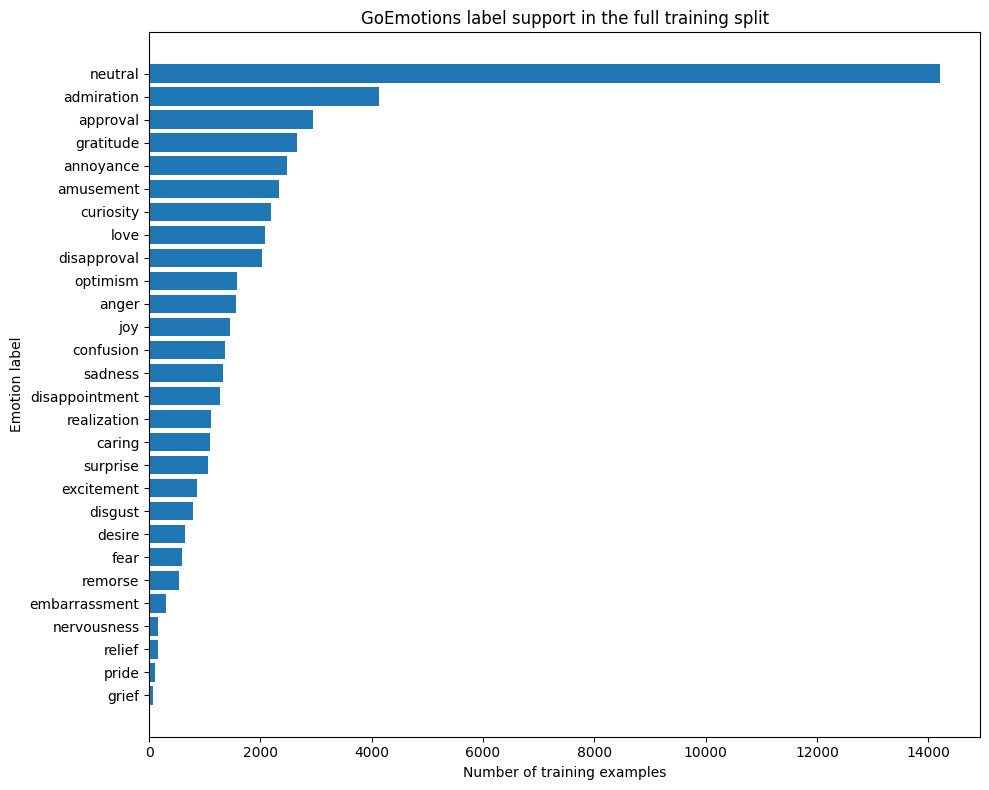

In [13]:
plot_df = support_df.sort_values("train", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["label"], plot_df["train"])
plt.xlabel("Number of training examples")
plt.ylabel("Emotion label")
plt.title("GoEmotions label support in the full training split")
plt.tight_layout()
plt.show()

In [14]:
def label_cardinality_counts(split_dataset):
    return Counter(len(label_ids) for label_ids in split_dataset["labels"])

In [15]:
cardinality_rows = []

for split_name, split_dataset in dataset.items():
    cardinality_counter = label_cardinality_counts(split_dataset)

    for number_of_labels, count in sorted(cardinality_counter.items()):
        cardinality_rows.append(
            {
                "split": split_name,
                "number_of_labels": number_of_labels,
                "example_count": count,
                "proportion": count / len(split_dataset),
            }
        )

cardinality_df = pd.DataFrame(cardinality_rows)

display(cardinality_df)

,split,number_of_labels,example_count,proportion
0,train,1,36308,0.836397
1,train,2,6541,0.150680
2,train,3,532,0.012255
3,train,4,28,0.000645
4,train,5,1,0.000023
5,validation,1,4548,0.838187
6,validation,2,809,0.149097
7,validation,3,62,0.011426
8,validation,4,7,0.001290
9,test,1,4590,0.845771


In [16]:
for split_name, split_dataset in dataset.items():
    cardinalities = np.array(
        [len(label_ids) for label_ids in split_dataset["labels"]]
    )

    print(
        f"{split_name}: "
        f"mean labels/example = {cardinalities.mean():.3f}, "
        f"median = {np.median(cardinalities):.1f}, "
        f"max = {cardinalities.max()}"
    )

train: mean labels/example = 1.177, median = 1.0, max = 5
validation: mean labels/example = 1.176, median = 1.0, max = 4
test: mean labels/example = 1.166, median = 1.0, max = 4


In [17]:
def build_cooccurrence_matrix(split_dataset, num_labels):
    matrix = np.zeros((num_labels, num_labels), dtype=int)

    for label_ids in split_dataset["labels"]:
        unique_labels = sorted(set(label_ids))

        for label_id in unique_labels:
            matrix[label_id, label_id] += 1

        for label_a, label_b in combinations(unique_labels, 2):
            matrix[label_a, label_b] += 1
            matrix[label_b, label_a] += 1

    return matrix

In [18]:
train_cooccurrence = build_cooccurrence_matrix(
    dataset["train"],
    num_labels,
)

cooccurrence_df = pd.DataFrame(
    train_cooccurrence,
    index=label_names,
    columns=label_names,
)

display(cooccurrence_df)

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
admiration,4130,84,5,25,246,31,24,65,33,24,14,10,3,75,14,279,1,126,192,1,106,23,41,4,9,16,53,94
amusement,84,2328,15,40,57,8,24,48,10,10,20,9,8,13,3,82,0,90,55,2,31,1,34,3,10,18,13,57
anger,5,15,1567,269,8,9,8,11,4,30,43,53,6,0,5,11,0,4,7,2,6,1,4,2,3,17,10,73
annoyance,25,40,269,2470,37,13,24,45,12,110,178,80,9,4,11,20,2,6,12,1,24,2,26,4,8,26,9,132
approval,246,57,8,37,2939,65,20,36,18,23,19,13,1,25,8,62,0,41,60,3,100,5,80,7,12,10,14,202
caring,31,8,9,13,65,1087,1,15,11,10,14,2,2,2,6,24,3,23,41,4,90,0,15,6,14,29,3,61
confusion,24,24,8,24,20,1,1368,212,2,16,22,3,2,4,8,24,0,8,10,2,5,0,20,1,5,6,23,98
curiosity,65,48,11,45,36,15,212,2191,11,21,31,11,10,21,11,31,0,14,25,3,28,0,33,1,14,23,57,118
desire,33,10,4,12,18,11,2,11,641,12,5,3,0,10,1,13,1,8,27,0,64,0,12,0,2,11,1,27
disappointment,24,10,30,110,23,10,16,21,12,1269,54,20,10,4,6,8,4,7,10,7,17,0,30,0,15,133,11,65


In [19]:
pair_rows = []

for label_a in range(num_labels):
    for label_b in range(label_a + 1, num_labels):
        count = train_cooccurrence[label_a, label_b]

        if count > 0:
            pair_rows.append(
                {
                    "label_a": label_names[label_a],
                    "label_b": label_names[label_b],
                    "cooccurrence_count": count,
                }
            )

pair_df = pd.DataFrame(pair_rows).sort_values(
    "cooccurrence_count",
    ascending=False,
)

display(pair_df.head(30))

,label_a,label_b,cooccurrence_count
14,admiration,gratitude,279
52,anger,annoyance,269
3,admiration,approval,246
142,confusion,curiosity,212
120,approval,neutral,202
17,admiration,love,192
81,annoyance,disapproval,178
207,disappointment,sadness,133
98,annoyance,neutral,132
16,admiration,joy,126


In [20]:
train_support = support_by_split["train"]

conditional_matrix = np.zeros(
    (num_labels, num_labels),
    dtype=float,
)

for source_label in range(num_labels):
    source_count = train_support[source_label]

    if source_count == 0:
        continue

    for target_label in range(num_labels):
        conditional_matrix[source_label, target_label] = (
            train_cooccurrence[source_label, target_label]
            / source_count
        )

conditional_df = pd.DataFrame(
    conditional_matrix,
    index=label_names,
    columns=label_names,
)

In [21]:
print(
    "P(sadness | remorse) =",
    conditional_df.loc["remorse", "sadness"],
)

print(
    "P(remorse | sadness) =",
    conditional_df.loc["sadness", "remorse"],
)

P(sadness | remorse) = 0.11009174311926606
P(remorse | sadness) = 0.04524886877828054


In [22]:
important_pairs = [
    ("remorse", "sadness"),
    ("grief", "sadness"),
    ("grief", "remorse"),
    ("relief", "joy"),
    ("relief", "gratitude"),
    ("relief", "pride"),
    ("nervousness", "fear"),
    ("pride", "admiration"),
]

relationship_rows = []

for label_a, label_b in important_pairs:
    relationship_rows.append(
        {
            "label_a": label_a,
            "label_b": label_b,
            "support_a": int(
                support_df.loc[support_df["label"] == label_a, "train"].iloc[0]
            ),
            "support_b": int(
                support_df.loc[support_df["label"] == label_b, "train"].iloc[0]
            ),
            "cooccurrence": int(
                cooccurrence_df.loc[label_a, label_b]
            ),
            f"P({label_b}|{label_a})": conditional_df.loc[label_a, label_b],
            f"P({label_a}|{label_b})": conditional_df.loc[label_b, label_a],
        }
    )

important_relationships_df = pd.DataFrame(relationship_rows)

display(important_relationships_df)

,label_a,label_b,support_a,support_b,cooccurrence,P(sadness|remorse),P(remorse|sadness),P(sadness|grief),P(grief|sadness),P(remorse|grief),P(grief|remorse),P(joy|relief),P(relief|joy),P(gratitude|relief),P(relief|gratitude),P(pride|relief),P(relief|pride),P(fear|nervousness),P(nervousness|fear),P(admiration|pride),P(pride|admiration)
0,remorse,sadness,545,1326,60,0.110092,0.045249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,grief,sadness,77,1326,22,NaN,NaN,0.285714,0.016591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,grief,remorse,77,545,3,NaN,NaN,NaN,NaN,0.038961,0.005505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,relief,joy,153,1452,9,NaN,NaN,NaN,NaN,NaN,NaN,0.058824,0.006198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,relief,gratitude,153,2662,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065359,0.003757,NaN,NaN,NaN,NaN,NaN,NaN
5,relief,pride,153,111,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
6,nervousness,fear,164,596,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.207317,0.057047,NaN,NaN
7,pride,admiration,111,4130,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.207207,0.005569


In [23]:
top_relationship_rows = []

for source_label_id, source_label_name in enumerate(label_names):
    target_scores = conditional_matrix[source_label_id].copy()

    # Saját magát ne vegyük figyelembe.
    target_scores[source_label_id] = -1

    top_target_ids = np.argsort(target_scores)[::-1][:5]

    for rank, target_label_id in enumerate(top_target_ids, start=1):
        top_relationship_rows.append(
            {
                "source_label": source_label_name,
                "rank": rank,
                "target_label": label_names[target_label_id],
                "conditional_probability": target_scores[target_label_id],
                "cooccurrence_count": train_cooccurrence[
                    source_label_id,
                    target_label_id,
                ],
            }
        )

top_relationships_df = pd.DataFrame(top_relationship_rows)

display(
    top_relationships_df[
        top_relationships_df["source_label"].isin(
            ["grief", "relief", "remorse", "sadness"]
        )
    ]
)

,source_label,rank,target_label,conditional_probability,cooccurrence_count
80,grief,1,sadness,0.285714,22
81,grief,2,disappointment,0.051948,4
82,grief,3,caring,0.038961,3
83,grief,4,remorse,0.038961,3
84,grief,5,surprise,0.025974,2
115,relief,1,gratitude,0.065359,10
116,relief,2,joy,0.058824,9
117,relief,3,neutral,0.052288,8
118,relief,4,approval,0.045752,7
119,relief,5,caring,0.039216,6


In [24]:
def show_examples_for_label(
    split_dataset,
    target_label,
    label_names,
    max_examples=10,
    require_co_label=None,
):
    target_label_id = label_names.index(target_label)

    if require_co_label is not None:
        co_label_id = label_names.index(require_co_label)
    else:
        co_label_id = None

    rows = []

    for example_index, example in enumerate(split_dataset):
        label_ids = example["labels"]

        if target_label_id not in label_ids:
            continue

        if co_label_id is not None and co_label_id not in label_ids:
            continue

        rows.append(
            {
                "example_index": example_index,
                "text": example["text"],
                "labels": [label_names[label_id] for label_id in label_ids],
            }
        )

        if len(rows) >= max_examples:
            break

    return pd.DataFrame(rows)

In [25]:
display(
    show_examples_for_label(
        dataset["train"],
        target_label="grief",
        label_names=label_names,
        max_examples=20,
    )
)

,example_index,text,labels
0,27,I miss them being alive,"[grief, sadness]"
1,42,I read on a different post that he died shortly after of internal injuries.,"[grief, neutral]"
2,350,Thats insane. Someone died like 2 years ago after a bolt got kicked up by a truck and went through his windshield and hit him on 146 in LaPorte,[grief]
3,387,Sad. My condolences to her family.,"[grief, sadness]"
4,572,I kill them all and THEN overwrite my only save. I'm bonkers.,[grief]
5,826,I'm so sorry about your friend. What was he like?,"[grief, sadness]"
6,1291,youve never played against a good support [NAME] then,[grief]
7,2774,"Dude, she had just lost her baby, too.","[grief, sadness]"
8,2983,I’m very sorry for the loss of your friend.,"[grief, sadness]"
9,4395,I am so sorry to hear about your wife’s tragic injury.,"[grief, sadness]"


In [26]:
display(
    show_examples_for_label(
        dataset["train"],
        target_label="relief",
        label_names=label_names,
        max_examples=20,
    )
)

,example_index,text,labels
0,147,"Glad you feel better! My offer still stands though, if you need someone, I’m here",[relief]
1,376,Omg so glad I’m not alone,"[joy, relief]"
2,1240,No one comes here it’s cool,[relief]
3,1352,"Whenever I'm having a bad day, I watch a few eps of Cosmos to chill out.","[joy, relief]"
4,1453,It's such a relieving feeling to know you're finally gone. You never have to go back. You are so strong you got this!!,"[admiration, relief]"
5,1519,"I’m glad you fixed Minnesota, because there is a 0% chance we will go Red.",[relief]
6,1650,"Oh man, glad I'm not watching this with my extremely emetophobic mother",[relief]
7,1754,That's a welcome relief. Lol.,[relief]
8,2219,"At last, someone I can share this accomplishment with!",[relief]
9,2677,Also dont have to worry about ramos and robles walking in runs to lose games,[relief]


In [27]:
display(
    show_examples_for_label(
        dataset["train"],
        target_label="remorse",
        require_co_label="sadness",
        label_names=label_names,
        max_examples=20,
    )
)

,example_index,text,labels
0,399,"I wasn't meaning it as an insult or anything, sorry if it came off that way.","[remorse, sadness]"
1,1125,"Where the mask inside, too? Are air purifers not good enough for inside? Sorry for the dumb question... Just moved here this week.","[curiosity, remorse, sadness]"
2,1686,"Sorry i was thinking of the word ""Plaintiff""","[remorse, sadness]"
3,2178,I'm so sorry you were bullied in a place you should have felt safe.,"[remorse, sadness]"
4,2599,I'm so sorry. This is no way to be live or be treated. It's so immature and emotionally-abusive. I really hope your circumstances improve,"[remorse, sadness]"
5,4168,I feel digestive regret just looking at them.,"[disappointment, remorse, sadness]"
6,4331,i’m so sorry.....,"[remorse, sadness]"
7,4659,"Oh my gosh, my Dodger blue heart goes out to yours and your family. I am so sorry.","[remorse, sadness]"
8,5327,I'm sorry my Baby [NAME] joke made you so angry.,"[remorse, sadness]"
9,5406,"First of all, sorry for your loss. Keep in mind that funerals are for the people still alive not the person who has just died.","[remorse, sadness]"


In [28]:
remorse_id = label_names.index("remorse")
sadness_id = label_names.index("sadness")

rows = []

for example_index, example in enumerate(dataset["train"]):
    labels = set(example["labels"])

    if remorse_id in labels and sadness_id not in labels:
        rows.append(
            {
                "example_index": example_index,
                "text": example["text"],
                "labels": [label_names[label_id] for label_id in example["labels"]],
            }
        )

    if len(rows) >= 20:
        break

display(pd.DataFrame(rows))

,example_index,text,labels
0,92,"Apologies, I take it all back as I’ve just seen his latest effort",[remorse]
1,255,I'm sorry but as someone who travels alone I would be pissed if I was told I can't drink at the bar by myself.,"[annoyance, remorse]"
2,406,Eat too many whoppers and he'll be down with the sickness. Lma0 I'm sorry,[remorse]
3,535,"don't know any [NAME], sorry",[remorse]
4,631,"Sorry, but getting shot at causes an almost instinctive natural reflexive reaction to shoot back. I guess I'm just weird like that.",[remorse]
5,638,"Yeah, sorry, I was on the mobile site, and wasn't able to delete it.",[remorse]
6,793,Lmao I'm sorry!,[remorse]
7,866,"What are you even talking about? I'm sorry you don't like [NAME], get over it.",[remorse]
8,1074,"Didn't notice the date, sorry.",[remorse]
9,1099,I've seen a number of them on there. I regret seeing most of them but some are legit movies.,[remorse]


In [29]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [30]:
output_dir = Path(
    "/content/drive/MyDrive/goemotions_label_space_analysis"
)

output_dir.mkdir(parents=True, exist_ok=True)

support_df.to_csv(
    output_dir / "label_support_by_split.csv",
    index=False,
)

pair_df.to_csv(
    output_dir / "train_label_pair_cooccurrence.csv",
    index=False,
)

cooccurrence_df.to_csv(
    output_dir / "train_cooccurrence_matrix.csv",
)

conditional_df.to_csv(
    output_dir / "train_conditional_probability_matrix.csv",
)

top_relationships_df.to_csv(
    output_dir / "top_directional_label_relationships.csv",
    index=False,
)

print(f"Saved analysis files to: {output_dir}")

Saved analysis files to: /content/drive/MyDrive/goemotions_label_space_analysis


In [31]:
display(
    show_examples_for_label(
        dataset["train"],
        target_label="grief",
        require_co_label="sadness",
        label_names=label_names,
        max_examples=20,
    )
)

,example_index,text,labels
0,27,I miss them being alive,"[grief, sadness]"
1,387,Sad. My condolences to her family.,"[grief, sadness]"
2,826,I'm so sorry about your friend. What was he like?,"[grief, sadness]"
3,2774,"Dude, she had just lost her baby, too.","[grief, sadness]"
4,2983,I’m very sorry for the loss of your friend.,"[grief, sadness]"
5,4395,I am so sorry to hear about your wife’s tragic injury.,"[grief, sadness]"
6,6915,My life has been destroyed,"[grief, remorse, sadness]"
7,8661,"I’m broke, dealing with my own mental illness, and immediately concerned with just keeping the peace.","[grief, sadness]"
8,10639,She's passed away.,"[grief, sadness]"
9,14507,"My parents died. I wish they were someplace warm that I could visit them with their grandchild, and they could visit too.","[grief, sadness]"


In [32]:
display(
    show_examples_for_label(
        dataset["train"],
        target_label="relief",
        require_co_label="joy",
        label_names=label_names,
        max_examples=20,
    )
)

,example_index,text,labels
0,376,Omg so glad I’m not alone,"[joy, relief]"
1,1352,"Whenever I'm having a bad day, I watch a few eps of Cosmos to chill out.","[joy, relief]"
2,13341,I've finally found my people who know the struggle.,"[joy, relief]"
3,23698,yes and I'm glad that this nonsense stops with me,"[joy, relief]"
4,31232,That’s horrible. You definitely didn’t deserve it. I’m glad to hear you’re doing OK now.,"[disgust, joy, relief]"
5,33811,Ending a relationship with a toxic person is so freeing. Congratulations!,"[joy, relief]"
6,34256,Obviously has played on her mind for that long... glad she apologised,"[joy, relief]"
7,34498,This is what I'm currently dealing with and I'm glad I read this. Nice reminder thank you lol.,"[amusement, gratitude, joy, relief]"
8,42920,Well [NAME] just missed...so there’s that bit of good news,"[joy, relief]"


In [33]:
display(
    show_examples_for_label(
        dataset["train"],
        target_label="relief",
        require_co_label="gratitude",
        label_names=label_names,
        max_examples=20,
    )
)

,example_index,text,labels
0,2794,Thank [NAME] for the adult spammers on my susbscribed NSFW subreddits.,"[gratitude, relief]"
1,3769,"You’re very right, I’m relieved I was free of this man before anything else happened. Thank [NAME]! And thanks for your kind words","[approval, gratitude, relief]"
2,4189,Thank god. This place was authoritarian.,"[gratitude, relief]"
3,4931,That's how you think hes trying to input something. Glad it was my way home.,"[gratitude, relief]"
4,13793,"So glad you are safe. It looks like icy conditions, too, so that is great that you were able to avoid this.","[caring, gratitude, relief]"
5,18013,Oh thank [NAME],"[gratitude, relief]"
6,19727,Hot damn! Thankfully only a bump to the head.,"[gratitude, relief]"
7,21251,Thanks :).. My issue got solved :) . YT on Twitter never helps.. they just do the basic troubleshooting.,"[annoyance, gratitude, relief]"
8,34498,This is what I'm currently dealing with and I'm glad I read this. Nice reminder thank you lol.,"[amusement, gratitude, joy, relief]"
9,34603,Glad that's settled,"[gratitude, relief]"
